<a href="https://colab.research.google.com/github/robitussin/CCDATSCL_EXERCISES/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4

This exercise focuses on data visualization and interpretation using a real-world COVID-19 dataset. The dataset contains daily records of confirmed cases, deaths, recoveries, and active cases across countries and regions, along with temporal and geographic information.
The goal of this exercise is not only to create charts, but to choose appropriate visualizations, apply correct data aggregation, and draw meaningful insights from the data. You will work with time-based, categorical, numerical, and geographic variables, and you are expected to think critically about how design choices affect interpretation.

Your visualizations should follow good practices:
- Use clear titles, axis labels, and legends
- Choose chart types appropriate to the data and question
- Avoid misleading scales or cluttered designs
- Clearly explain patterns, trends, or anomalies you observe

Unless stated otherwise, you may filter, aggregate, or group the data as needed.

<img src="https://d3i6fh83elv35t.cloudfront.net/static/2020/03/Screen-Shot-2020-03-05-at-6.29.29-PM-1024x574.png"/>

In [1]:
# Ensure required packages are available in the current Jupyter kernel
import importlib
import subprocess
import sys

required_packages = ["kagglehub", "folium"]
for pkg in required_packages:
    try:
        importlib.import_module(pkg)
    except ImportError:
        # Install the package only if it's missing
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"]) 



d:\Dev\VSCode_Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import pandas as pd
import kagglehub as kh

# Download or reuse the latest version of the dataset
DATASET_ID = "imdevskp/corona-virus-report"
path = kh.dataset_download(DATASET_ID)

print(f"Path to dataset files: {path}")

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\imdevskp\corona-virus-report\versions\166


In [3]:
from pathlib import Path
import pandas as pd

data_dir = Path(path)
print("Directory exists:", data_dir.is_dir())

contents = sorted(p.name for p in data_dir.iterdir())
print("Files in dataset directory:", contents)

mydataset = data_dir / "full_grouped.csv"
print("Loading dataset from:", mydataset)

df = pd.read_csv(mydataset)


Directory exists: True
Files in dataset directory: ['country_wise_latest.csv', 'covid_19_clean_complete.csv', 'day_wise.csv', 'full_grouped.csv', 'usa_county_wise.csv', 'worldometer_data.csv']
Loading dataset from: C:\Users\user\.cache\kagglehub\datasets\imdevskp\corona-virus-report\versions\166\full_grouped.csv


In [4]:
_ = df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Date            35156 non-null  str  
 1   Country/Region  35156 non-null  str  
 2   Confirmed       35156 non-null  int64
 3   Deaths          35156 non-null  int64
 4   Recovered       35156 non-null  int64
 5   Active          35156 non-null  int64
 6   New cases       35156 non-null  int64
 7   New deaths      35156 non-null  int64
 8   New recovered   35156 non-null  int64
 9   WHO Region      35156 non-null  str  
dtypes: int64(7), str(3)
memory usage: 2.7 MB


In [5]:
first_rows = df.head()
first_rows

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [6]:
philippines_df = df[df["Country/Region"].eq("Philippines")]
philippines_df

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
133,2020-01-22,Philippines,0,0,0,0,0,0,0,Western Pacific
320,2020-01-23,Philippines,0,0,0,0,0,0,0,Western Pacific
507,2020-01-24,Philippines,0,0,0,0,0,0,0,Western Pacific
694,2020-01-25,Philippines,0,0,0,0,0,0,0,Western Pacific
881,2020-01-26,Philippines,0,0,0,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
34354,2020-07-23,Philippines,74390,1871,24383,48136,2121,28,760,Western Pacific
34541,2020-07-24,Philippines,76444,1879,24502,50063,2054,8,119,Western Pacific
34728,2020-07-25,Philippines,78412,1897,25752,50763,1968,18,1250,Western Pacific
34915,2020-07-26,Philippines,80448,1932,26110,52406,2036,35,358,Western Pacific


## A. Time-Based Visualizations

1. Global Trend `(5 pts)`

Aggregate the data by Date and create a line chart showing the global number of confirmed COVID-19 cases over time.

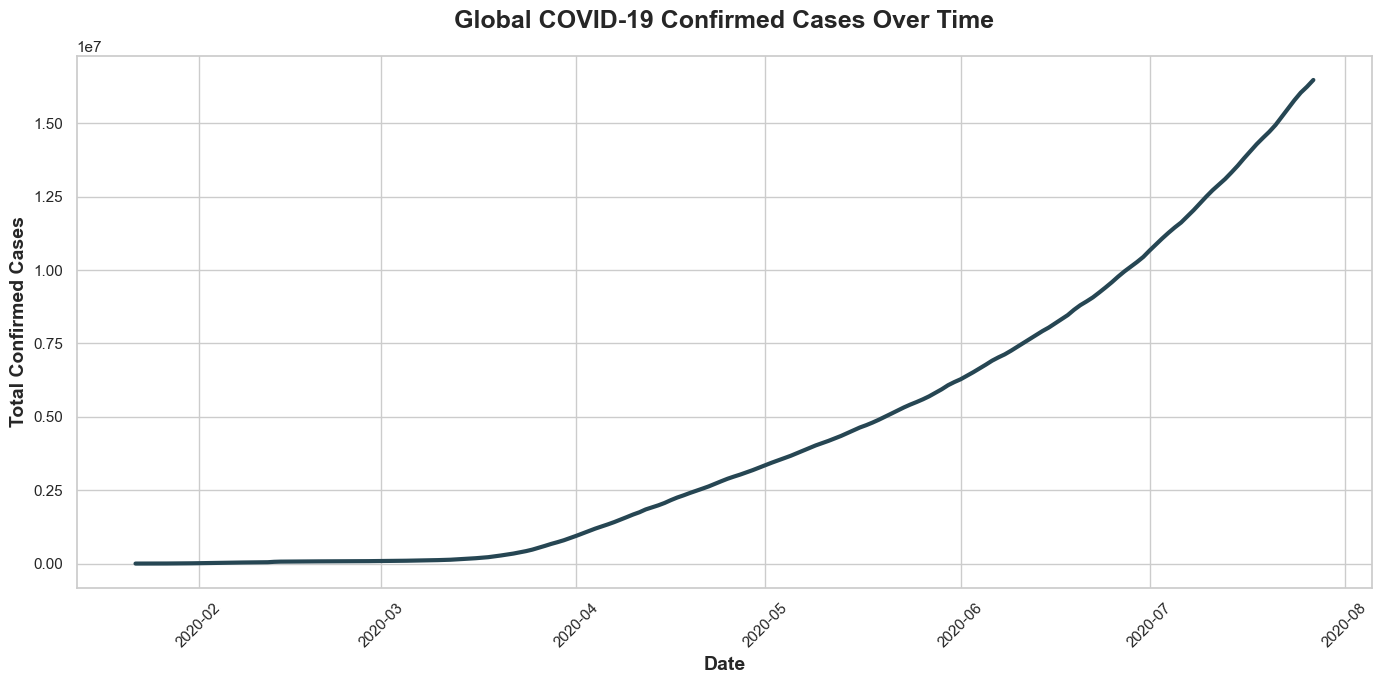

First recorded date: 2020-01-22
Last recorded date: 2020-07-27
Total confirmed cases: 16,480,485


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a consistent visual style
sns.set_theme(style="whitegrid")

# Work on a copy to avoid modifying the original frame in-place
global_df = df.copy()
global_df["Date"] = pd.to_datetime(global_df["Date"])

# Aggregate global confirmed cases by date
global_cases = (
    global_df
    .groupby("Date", as_index=False)["Confirmed"]
    .sum()
    .sort_values("Date")
)

# Create line chart using matplotlib directly
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(global_cases["Date"], global_cases["Confirmed"], color="#264653", linewidth=3)
ax.set_title("Global COVID-19 Confirmed Cases Over Time", fontsize=18, fontweight="bold", pad=20)
ax.set_xlabel("Date", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Confirmed Cases", fontsize=14, fontweight="bold")
for label in ax.get_xticklabels():
    label.set_rotation(45)
fig.tight_layout()
plt.show()

# Print statistics
first_date = global_cases["Date"].min().strftime("%Y-%m-%d")
last_date = global_cases["Date"].max().strftime("%Y-%m-%d")
max_confirmed = global_cases["Confirmed"].max()

print(f"First recorded date: {first_date}")
print(f"Last recorded date: {last_date}")
print(f"Total confirmed cases: {max_confirmed:,}")

2. Country-Level Trends `(5 pts)`

Select three countries and visualize their confirmed case counts over time on the same plot.

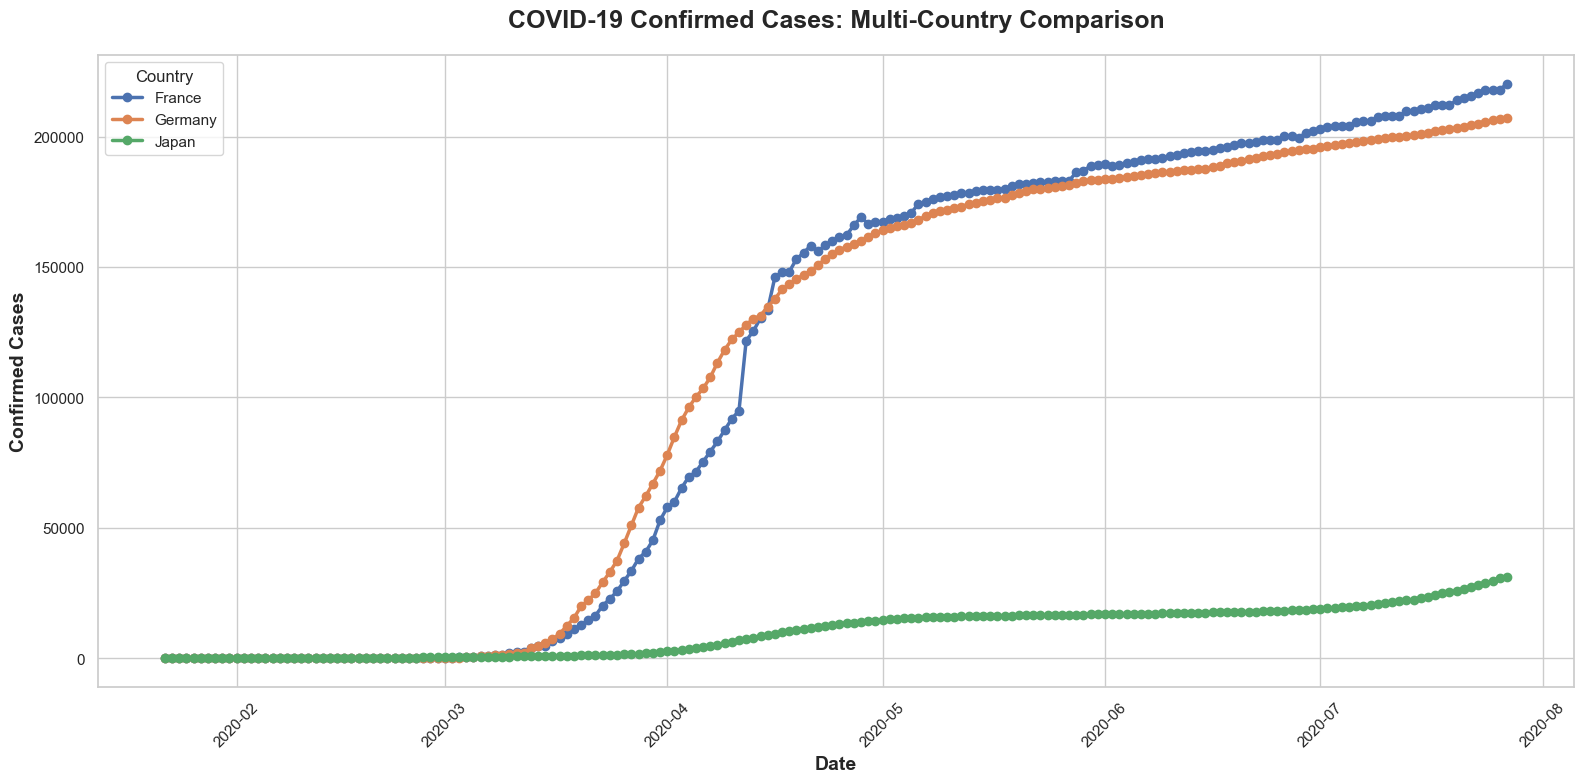

In [8]:
# Select three countries for comparison
selected_countries = ["France", "Germany", "Japan"]

# Filter data for selected countries
subset = df[df["Country/Region"].isin(selected_countries)].copy()
subset["Date"] = pd.to_datetime(subset["Date"])

# Aggregate by date and country and pivot for plotting
country_pivot = (
    subset
    .groupby(["Date", "Country/Region"])["Confirmed"]
    .sum()
    .unstack("Country/Region")
    .sort_index()
)

# Create visualization using matplotlib
plt.figure(figsize=(16, 8))
for country in country_pivot.columns:
    plt.plot(country_pivot.index, country_pivot[country], marker="o", linewidth=2.5, label=country)

plt.title("COVID-19 Confirmed Cases: Multi-Country Comparison",
         fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Date", fontsize=14, fontweight="bold")
plt.ylabel("Confirmed Cases", fontsize=14, fontweight="bold")
plt.legend(title="Country", title_fontsize=12, fontsize=11, loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Active vs Recovered `(5 pts)`

For a selected country, create a line chart showing Active and Recovered cases over time.

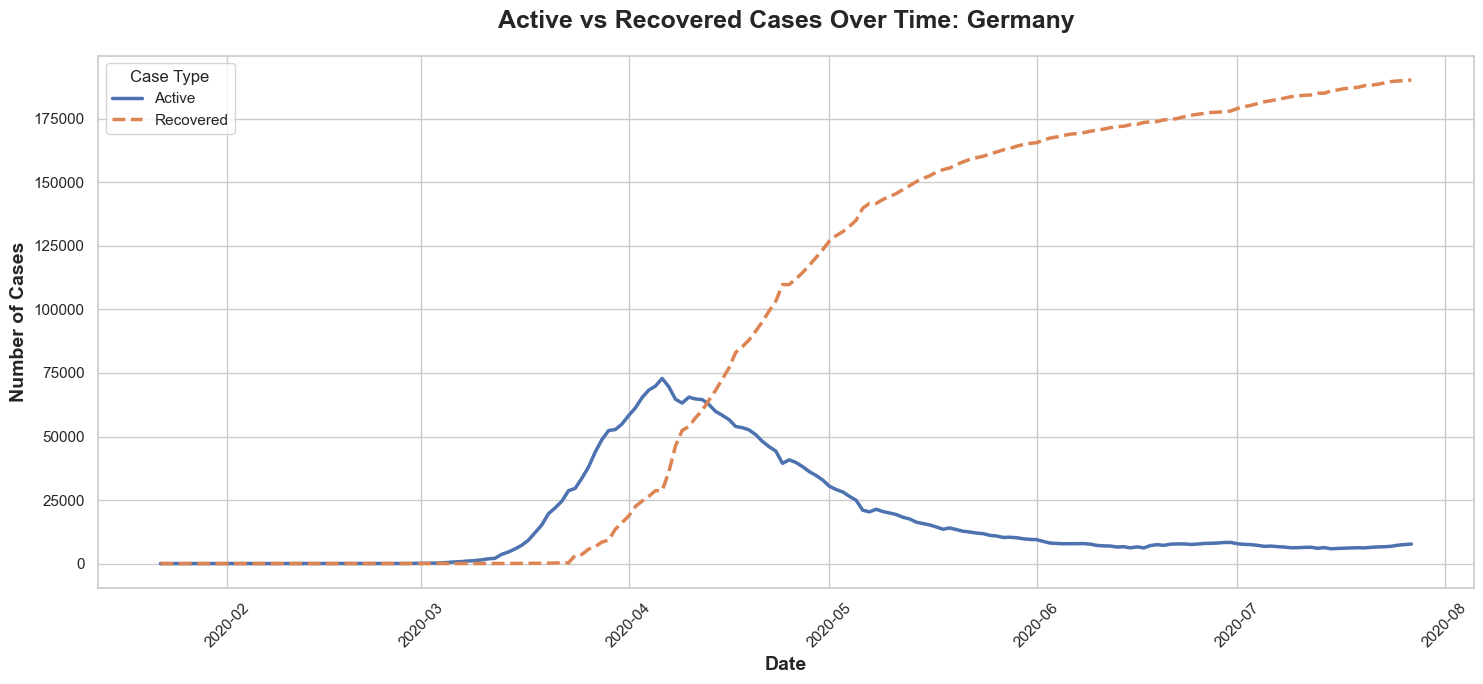

In [9]:
# Select Germany for analysis
analysis_country = "Germany"

# Filter data for Germany and ensure Date is datetime
germany_df = df[df["Country/Region"] == analysis_country].copy()
germany_df["Date"] = pd.to_datetime(germany_df["Date"])

# Aggregate Active and Recovered cases by date using groupby
germany_series = (
    germany_df
    .groupby("Date")[["Active", "Recovered"]]
    .sum()
    .sort_index()
)

# Create visualization with separate lines
plt.figure(figsize=(15, 7))
for col, style in zip(["Active", "Recovered"], ["-", "--"]):
    plt.plot(germany_series.index, germany_series[col], linestyle=style,
             linewidth=2.5, label=col)

plt.title(f"Active vs Recovered Cases Over Time: {analysis_country}",
         fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Date", fontsize=14, fontweight="bold")
plt.ylabel("Number of Cases", fontsize=14, fontweight="bold")
plt.legend(title="Case Type", title_fontsize=12, fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## B: Comparative Visualizations

4. Country Comparison `(5 pts)`

Using data from a single date, create a bar chart showing the top 10 countries by confirmed cases.

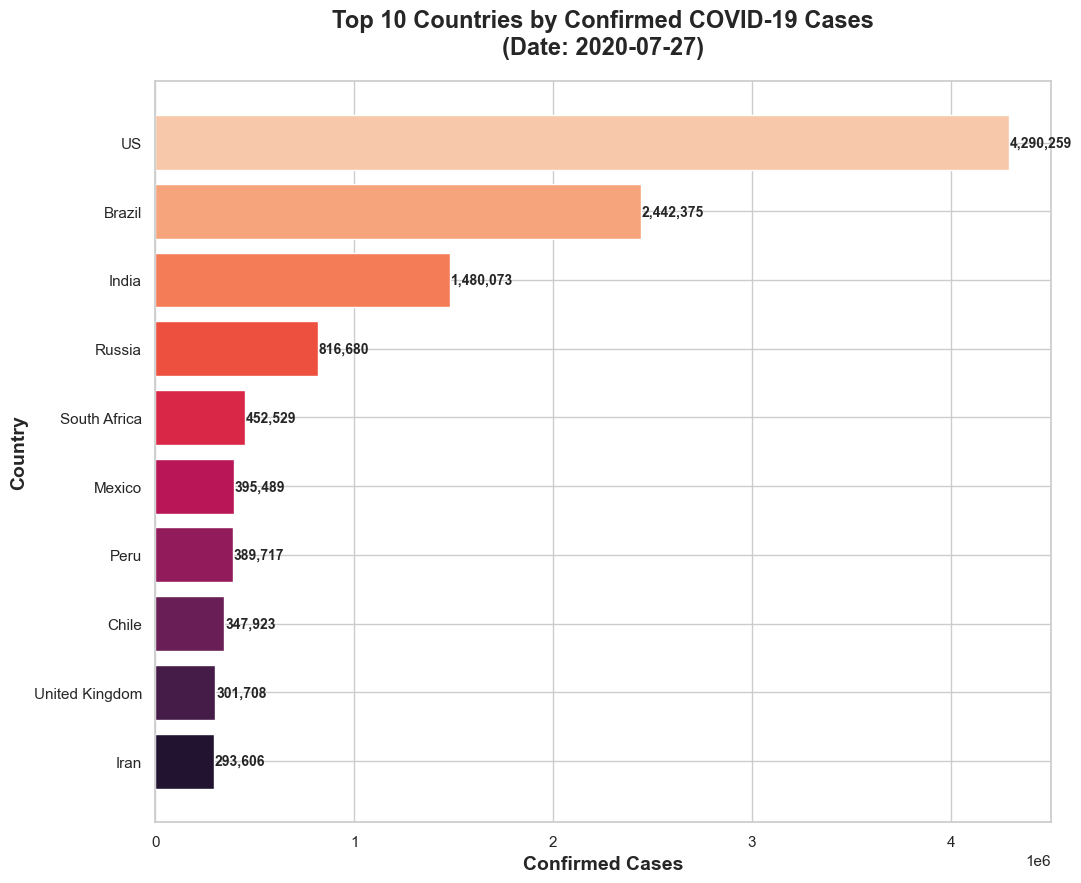

In [10]:
# Determine the latest date in the dataset
analysis_date = pd.to_datetime(df["Date"]).max()

# Filter data for that date
date_filtered = df[pd.to_datetime(df["Date"]).eq(analysis_date)]

# Aggregate by country
country_summary = (
    date_filtered
    .groupby("Country/Region", as_index=False)["Confirmed"]
    .sum()
)

# Prepare the top 10 countries
top_10_countries = (
    country_summary
    .sort_values("Confirmed", ascending=False)
    .head(10)
    .sort_values("Confirmed")
)

# Create bar chart using matplotlib
fig, ax = plt.subplots(figsize=(11, 9))
colors = sns.color_palette("rocket", n_colors=len(top_10_countries))
ax.barh(top_10_countries["Country/Region"], top_10_countries["Confirmed"], color=colors)
ax.set_title(
    f"Top 10 Countries by Confirmed COVID-19 Cases\n(Date: {analysis_date.strftime('%Y-%m-%d')})",
    fontsize=17, fontweight="bold", pad=20,
)
ax.set_xlabel("Confirmed Cases", fontsize=14, fontweight="bold")
ax.set_ylabel("Country", fontsize=14, fontweight="bold")

# Add value labels
for i, value in enumerate(top_10_countries["Confirmed"]):
    ax.text(value + 5000, i, f"{int(value):,}", va="center", fontsize=10, fontweight="bold")

fig.tight_layout()
plt.show()

5. WHO Region Comparison `(5 pts)`

Aggregate confirmed cases by WHO Region and visualize the result using a bar chart.

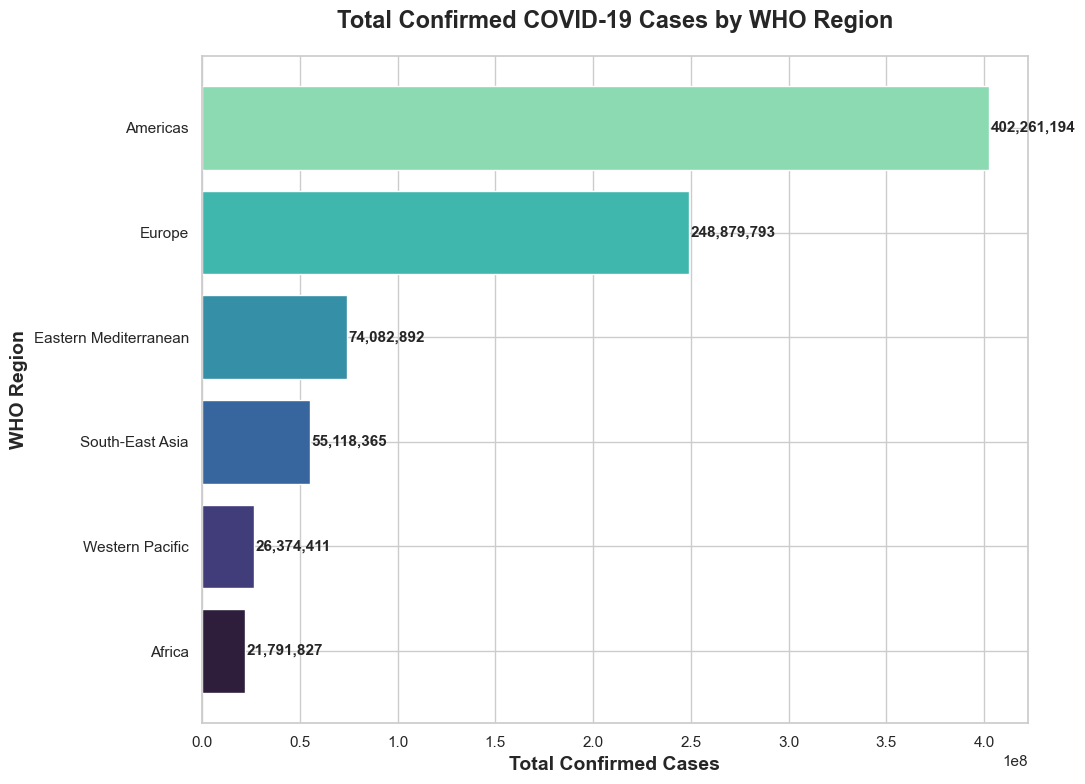

In [11]:
# Aggregate total confirmed cases by WHO Region
who_regions = (
    df.groupby("WHO Region", as_index=False)["Confirmed"]
      .sum()
      .sort_values("Confirmed", ascending=True)
)

# Create bar chart using matplotlib
fig, ax = plt.subplots(figsize=(11, 8))
colors = sns.color_palette("mako", n_colors=len(who_regions))
ax.barh(who_regions["WHO Region"], who_regions["Confirmed"], color=colors)
ax.set_title("Total Confirmed COVID-19 Cases by WHO Region",
             fontsize=17, fontweight="bold", pad=20)
ax.set_xlabel("Total Confirmed Cases", fontsize=14, fontweight="bold")
ax.set_ylabel("WHO Region", fontsize=14, fontweight="bold")

# Add value labels
for i, value in enumerate(who_regions["Confirmed"]):
    ax.text(value + 1_000_000, i, f"{int(value):,}",
            va="center", fontsize=11, fontweight="bold")

fig.tight_layout()
plt.show()

## C. Geographic Visualization

6. Geographic Spread `(10 pts)`

Using Latitude and Longitude, create a map-based visualization showing confirmed cases for a selected date.

In [12]:
import folium  # type: ignore[import]
from folium.plugins import HeatMap  # type: ignore[import]
import os

# Load geographic dataset if needed
if "geo_df" not in globals():
    geo_dataset = os.path.join(path, "covid_19_clean_complete.csv")
    geo_df = pd.read_csv(geo_dataset, parse_dates=["Date"])
    print("Loaded geographic dataset from:", geo_dataset)

# Use the most recent date in the dataset
latest_geo_date = geo_df["Date"].max()

geo_data = (
    geo_df.loc[geo_df["Date"] == latest_geo_date]
          .dropna(subset=["Lat", "Long"])
          .copy()
)

# Initialize map centered near the equator
base_map = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron",
)

# Build heatmap input as (lat, lon, weight)
heatmap_data = geo_data[["Lat", "Long", "Confirmed"]].values.tolist()

HeatMap(
    heatmap_data,
    min_opacity=0.25,
    radius=18,
    blur=12,
    gradient={0.3: "blue", 0.5: "cyan", 0.7: "yellow", 1: "red"},
).add_to(base_map)

# Mark top 20 countries by confirmed cases
for _, row in geo_data.nlargest(20, "Confirmed").iterrows():
    popup_html = (
        f"<b>{row['Country/Region']}</b><br>"
        f"Confirmed: {row['Confirmed']:,}<br>"
        f"Deaths: {row['Deaths']:,}<br>"
        f"Recovered: {row['Recovered']:,}<br>"
        f"Active: {row['Active']:,}"
    )
    folium.Marker(
        location=[row["Lat"], row["Long"]],
        popup=folium.Popup(popup_html, max_width=250),
        icon=folium.Icon(color="darkred", icon="exclamation-triangle", prefix="fa"),
    ).add_to(base_map)

base_map

Loaded geographic dataset from: C:\Users\user\.cache\kagglehub\datasets\imdevskp\corona-virus-report\versions\166\covid_19_clean_complete.csv


In [13]:
from pathlib import Path

geo_dataset_path = Path(path) / "covid_19_clean_complete.csv"
print("Loading geographic dataset from:", geo_dataset_path)

geo_df = pd.read_csv(geo_dataset_path, parse_dates=["Date"])
print("Columns in geo_df:", list(geo_df.columns))
geo_df.info()

Loading geographic dataset from: C:\Users\user\.cache\kagglehub\datasets\imdevskp\corona-virus-report\versions\166\covid_19_clean_complete.csv
Columns in geo_df: ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']
<class 'pandas.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  str           
 1   Country/Region  49068 non-null  str           
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[us]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  str        

7. Regional Clustering `(15 pts)`

Create a visualization that shows how confirmed cases are distributed geographically within a single WHO Region.

In [14]:
import folium  # type: ignore[import]
from folium.plugins import MarkerCluster  # type: ignore[import]

# Select Western Pacific region
region = "Western Pacific"

# Filter data for the chosen WHO region
region_data = geo_df[geo_df["WHO Region"] == region].copy()

# Get the latest date and filter
date_latest_region = region_data["Date"].max()
region_latest = region_data[region_data["Date"] == date_latest_region].dropna(subset=["Lat", "Long"])

# Calculate center coordinates
center_lat = region_latest["Lat"].mean()
center_lon = region_latest["Long"].mean()

# Create map
region_map = folium.Map(location=[center_lat, center_lon],
                        zoom_start=4, tiles="OpenStreetMap")

# Create marker cluster
cluster = MarkerCluster().add_to(region_map)

# Add markers with color based on case intensity
max_cases = region_latest["Confirmed"].max()

for _, row in region_latest.iterrows():
    intensity = row["Confirmed"] / max_cases if max_cases else 0
    if intensity > 0.5:
        icon_color = "red"
    elif intensity > 0.2:
        icon_color = "orange"
    else:
        icon_color = "green"

    popup_html = (
        f"<b>{row['Country/Region']}</b><br>"
        f"Confirmed: {row['Confirmed']:,}<br>"
        f"Deaths: {row['Deaths']:,}<br>"
        f"Recovered: {row['Recovered']:,}<br>"
        f"Active: {row['Active']:,}"
    )

    folium.Marker(
        location=[row["Lat"], row["Long"]],
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=f"{row['Country/Region']}: {row['Confirmed']:,} cases",
        icon=folium.Icon(color=icon_color, icon="info-sign", prefix="fa"),
    ).add_to(cluster)

# Add title
title_html = f'''
    <div style="position: fixed;
                top: 10px; left: 50px; width: 400px; height: 60px;
                background-color: white; z-index:9999; font-size:16px;
                border:2px solid grey; padding: 10px">
    <b>COVID-19 Cases in {region}</b><br>
    Date: {date_latest_region}
    </div>
    '''
region_map.get_root().html.add_child(folium.Element(title_html))

region_map